# Social Evaluation Model (SEM) — Interactive Demo

This notebook walks through the SEM step by step:

1. How knowledge state inference works (Equation 2)
2. How strategy inference works (Equation 3)
3. How the evaluation function combines them (Equation 1)
4. Case Study 1: Numerical (im)precision
5. Case Study 2: Pragmatic violations
6. Exploring the effect of different parameters

Run cells top to bottom. All parameters are clearly marked and easy to edit.

In [1]:
import sys
sys.path.insert(0, '..')   # make sem/ and case_studies/ importable

from sem.model import SEMScenario
from case_studies.cs1_imprecision import (
    build_scenario as build_cs1,
    target_effects as effects_cs1,
    UTTERANCES as CS1_V,
    CONTEXTS   as CS1_C,
    ATTRIBUTES as CS1_A,
)
from case_studies.cs2_pragmatic_violations import (
    build_scenario as build_cs2,
    target_effects as effects_cs2,
    UTTERANCES as CS2_V,
    ATTRIBUTES as CS2_A,
)
from sem.plotting import plot_cs1, plot_cs2

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['text.usetex'] = False  # set True if LaTeX is installed

print('Imports OK')

Imports OK


---
## 1 — Knowledge State Inference  P(k | v)

Given that the speaker said **v**, how likely is each knowledge state **k**?

This is Equation 2 in the paper:

$$P(k \mid v) = \frac{P(k) \cdot \chi_t(k, v)}{\sum_{k'} P(k') \cdot \chi_t(k', v)}$$

where $\chi_t(k, v) = 1$ if $v$ is a truthful utterance under knowledge state $k$.

In [2]:
# Build the Case Study 1 scenario with balanced (default) parameters
scenario = build_cs1(omega=0.5)

print('P(k | v) — knowledge state posteriors')
print(f'{"":12} {"v_prc":>8} {"v_apx":>8}')
print('-' * 30)
for k in scenario.knowledge_states:
    p_prc = scenario.prob_k(k, 'v_prc')
    p_apx = scenario.prob_k(k, 'v_apx')
    print(f'{k:<12} {p_prc:>8.3f} {p_apx:>8.3f}')

print()
print('Interpretation:')
print('  After v_prc: listener is certain the speaker knows the exact value (k_p = 1.0)')
print('  After v_apx: both knowledge states remain possible (50/50 under uniform priors)')

P(k | v) — knowledge state posteriors
                v_prc    v_apx
------------------------------
k_p             1.000    0.500
k_np            0.000    0.500

Interpretation:
  After v_prc: listener is certain the speaker knows the exact value (k_p = 1.0)
  After v_apx: both knowledge states remain possible (50/50 under uniform priors)


---
## 2 — Strategy Inference  P(m | k, v, c)

Given knowledge state **k**, utterance **v**, and context **c**, how likely is each strategy **m**?

This is Equation 3. The key insight from Figure 4(c) in the paper:
- In **c_LP** (low precision needed), a precise utterance can only come from **m_max** 
- In **c_HP** (high precision needed), a precise utterance is consistent with both **m_max** and **m_sit**

In [3]:
print('P(m | k_p, v_prc, c)  —  strategy posterior after precise utterance, given k_p')
print(f'{"":8} {"c_HP":>8} {"c_LP":>8}')
print('-' * 28)
for m in scenario.strategies:
    p_hp = scenario.prob_m(m, 'k_p', 'c_HP', 'v_prc')
    p_lp = scenario.prob_m(m, 'k_p', 'c_LP', 'v_prc')
    print(f'{m:<8} {p_hp:>8.3f} {p_lp:>8.3f}')

print()
print('In c_LP: precise utterance uniquely implies m_max (always precise by nature)')
print('In c_HP: m_max and m_sit are both consistent (the context "explains" the precision)')

P(m | k_p, v_prc, c)  —  strategy posterior after precise utterance, given k_p
             c_HP     c_LP
----------------------------
m_max       0.500    1.000
m_sit       0.500    0.000
m_min       0.000    0.000

In c_LP: precise utterance uniquely implies m_max (always precise by nature)
In c_HP: m_max and m_sit are both consistent (the context "explains" the precision)


---
## 3 — Evaluation Scores  E_L(a | v, c)

Now we combine knowledge and strategy inference into a full social evaluation.

$$E_L(a \mid v, c) = \sum_k \sum_m P(k \mid v) \cdot P(m \mid k, v, c) \cdot I(a \mid k, m;\, \omega)$$

In [4]:
scores = scenario.evaluate_all()

print('E_L scores — Case Study 1 (balanced model: ω=0.5, uniform priors)')
print(f'{"":12} {"c_HP / v_prc":>14} {"c_HP / v_apx":>14} {"c_LP / v_prc":>14} {"c_LP / v_apx":>14}')
print('-' * 70)
for a in CS1_A:
    vals = [scores[a][v][c] for c in CS1_C for v in CS1_V]
    print(f'{a:<12} {vals[0]:>14.3f} {vals[1]:>14.3f} {vals[2]:>14.3f} {vals[3]:>14.3f}')

E_L scores — Case Study 1 (balanced model: ω=0.5, uniform priors)
               c_HP / v_prc   c_HP / v_apx   c_LP / v_prc   c_LP / v_apx
----------------------------------------------------------------------
a_comp                0.750         -0.250          0.500          0.000
a_like                0.250          0.083          0.000          0.208
a_ped                 0.250         -0.167          0.500         -0.167


---
## 4 — Case Study 1: Numerical (Im)Precision

Reproduces Figure 6 from the paper.

In [5]:
# Check all 4 target empirical effects
effects = effects_cs1(scores)
labels = [
    'Effect 1: PRECISE > APPROX on competence (across contexts)',
    'Effect 2: PRECISE > APPROX on pedantry (across contexts)',
    'Effect 3: Competence gap larger in c_HP than c_LP',
    'Effect 4: Likeability gap larger in c_HP than c_LP',
]
for label, result in zip(labels, effects):
    mark = '✓' if result else '✗'
    print(f'  {mark}  {label}')
print(f'\nAll effects correct: {all(effects)}')

  ✓  Effect 1: PRECISE > APPROX on competence (across contexts)
  ✓  Effect 2: PRECISE > APPROX on pedantry (across contexts)
  ✓  Effect 3: Competence gap larger in c_HP than c_LP
  ✓  Effect 4: Likeability gap larger in c_HP than c_LP

All effects correct: True


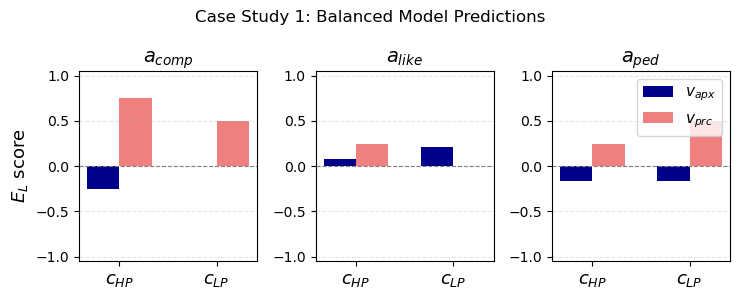

In [6]:
# Plot — reproduces Figure 6
fig = plot_cs1(scores, use_latex=False, title='Case Study 1: Balanced Model Predictions')
plt.show()

---
## 5 — Case Study 2: Pragmatic Violations

Reproduces Figure 8 from the paper.  
Based on Beltrama & Papafragou (2023).

In [7]:
scenario2 = build_cs2(omega=0.5)
scores2   = scenario2.evaluate_all()
c         = 'c_topic'

print('E_L scores — Case Study 2 (balanced model)')
print(f'{"":10} {"a_comp":>10} {"a_like":>10}')
print('-' * 32)
for v in CS2_V:
    vals = [scores2[a][v][c] for a in CS2_A]
    print(f'{v:<10} {vals[0]:>10.3f} {vals[1]:>10.3f}')

print()
effects2 = effects_cs2(scores2)
labels2  = [
    'Effect 1: Relevant > Irrelevant on competence',
    'Effect 2: Relevant > Irrelevant on likeability',
    'Effect 3: High-info > Low-info on competence',
    'Effect 4: High-info > Low-info on likeability',
    'Effect 5: Competence gap larger when relevant',
    'Effect 6: Likeability gap larger when relevant',
]
for label, result in zip(labels2, effects2):
    mark = '✓' if result else '✗'
    print(f'  {mark}  {label}')
print(f'\nAll effects correct: {all(effects2)}')

E_L scores — Case Study 2 (balanced model)
               a_comp     a_like
--------------------------------
v_A             1.000      0.500
v_a             0.500     -0.125
v_B            -0.500     -0.750
v_b            -0.500     -0.750

  ✓  Effect 1: Relevant > Irrelevant on competence
  ✓  Effect 2: Relevant > Irrelevant on likeability
  ✓  Effect 3: High-info > Low-info on competence
  ✓  Effect 4: High-info > Low-info on likeability
  ✓  Effect 5: Competence gap larger when relevant
  ✓  Effect 6: Likeability gap larger when relevant

All effects correct: True


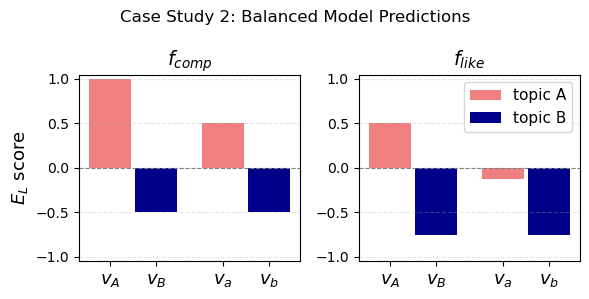

In [8]:
fig2 = plot_cs2(scores2, use_latex=False, title='Case Study 2: Balanced Model Predictions')
plt.show()

---
## 6 — Parameter Exploration

Try different values of ω and the priors to see how the model responds.

**Edit the parameters in the cell below and re-run.**

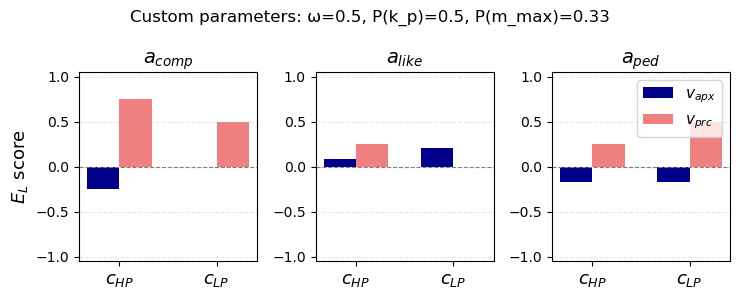

Effect predictions:
  ✓  Effect 1: Effect 1: PRECISE > APPROX on competence (across contexts)
  ✓  Effect 2: Effect 2: PRECISE > APPROX on pedantry (across contexts)
  ✓  Effect 3: Effect 3: Competence gap larger in c_HP than c_LP
  ✓  Effect 4: Effect 4: Likeability gap larger in c_HP than c_LP


In [9]:
# ============================================================
#  EDIT THESE PARAMETERS
# ============================================================

OMEGA = 0.5          # weight for knowledge vs. motivation (0=only motivation, 1=only knowledge)

PRIORS_K = {
    'k_p':  0.5,     # prior probability: speaker knows exact value
    'k_np': 0.5,     # prior probability: speaker only has approximate knowledge
}

PRIORS_M = {
    'm_max': 1/3,    # prior: speaker is always maximally precise
    'm_sit': 1/3,    # prior: speaker adapts precision to context
    'm_min': 1/3,    # prior: speaker is always minimally precise
}

# ============================================================

custom_scenario = build_cs1(omega=OMEGA, priors_K=PRIORS_K, priors_M=PRIORS_M)
custom_scores   = custom_scenario.evaluate_all()
custom_effects  = effects_cs1(custom_scores)

fig = plot_cs1(
    custom_scores,
    use_latex=False,
    title=f'Custom parameters: ω={OMEGA}, P(k_p)={PRIORS_K["k_p"]}, P(m_max)={PRIORS_M["m_max"]:.2f}'
)
plt.show()

print('Effect predictions:')
for i, (label, result) in enumerate(zip(labels, custom_effects), 1):
    mark = '✓' if result else '✗'
    print(f'  {mark}  Effect {i}: {label}')

---
## 7 — Robustness Test (quick version)

Sweep the parameter space and count how often the model correctly predicts
all empirical effects.  

⚠️ The full sweep (step=0.02) takes several minutes. Use step=0.1 for a
quick check here.

In [10]:
scenario_rob = build_cs1(omega=0.5)

result = scenario_rob.robustness_test(
    effects_fn=effects_cs1,
    step=0.1,           # use 0.05 or 0.02 for paper-quality results
)

print(f"Parameter combinations tested: {result['total']}")
print(f"All 4 effects correct:         {result['all_correct']} ({result['rate_all']*100:.1f}%)")
print()
print('Per-effect success rate:')
for i, (label, n) in enumerate(zip(labels, result['per_effect']), 1):
    rate = n / result['total']
    print(f'  Effect {i}: {rate*100:.1f}%  — {label}')

if result['failures']:
    print(f"\nFailure cases: {len(result['failures'])}")
    print('First failure example:')
    f = result['failures'][0]
    print(f"  ω={f['omega']}, priors_K={f['priors_K']}, priors_M={f['priors_M']}")
    print(f"  Effects: {f['effects']}")

Parameter combinations tested: 2916
All 4 effects correct:         2916 (100.0%)

Per-effect success rate:
  Effect 1: 100.0%  — Effect 1: PRECISE > APPROX on competence (across contexts)
  Effect 2: 100.0%  — Effect 2: PRECISE > APPROX on pedantry (across contexts)
  Effect 3: 100.0%  — Effect 3: Competence gap larger in c_HP than c_LP
  Effect 4: 100.0%  — Effect 4: Likeability gap larger in c_HP than c_LP
